In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import random

def split_dataset(source_dir, output_dir, train_ratio=0.7):
    random.seed(42)  # for reproducibility

    # Create train and test directories
    train_dir = os.path.join(output_dir, 'train')
    test_dir = os.path.join(output_dir, 'test')
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path) if f.endswith('.png')]
        random.shuffle(images)

        split_index = int(len(images) * train_ratio)
        train_images = images[:split_index]
        test_images = images[split_index:]

        # Create class subfolders in train and test directories
        train_class_dir = os.path.join(train_dir, class_name)
        test_class_dir = os.path.join(test_dir, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(test_class_dir, exist_ok=True)

        # Copy files
        for img in train_images:
            shutil.copy2(os.path.join(class_path, img), os.path.join(train_class_dir, img))

        for img in test_images:
            shutil.copy2(os.path.join(class_path, img), os.path.join(test_class_dir, img))

        print(f"Processed class '{class_name}': {len(train_images)} train, {len(test_images)} test")

# Example usage
source_directory = r'/content/drive/Othercomputers/My Laptop/Project/Coconut Plantation/Applicatno/Texture Classification/Amrita_HS'
output_directory = r'/content/drive/Othercomputers/My Laptop/Project/Coconut Plantation/Applicatno/Texture Classification/Amrita_HS_split'
split_dataset(source_directory, output_directory)


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

# ======== Parameters ========
train_dir = r'/content/drive/Othercomputers/My Laptop/Project/Coconut Plantation/Applicatno/Texture Classification/Amrita_HS_split/train'
val_dir  = r'/content/drive/Othercomputers/My Laptop/Project/Coconut Plantation/Applicatno/Texture Classification/Amrita_HS_split/test'

batch_size = 16
num_epochs = 150
learning_rate = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_val_acc = 0.0

# ======== Transforms ========
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ======== Dataset & DataLoader ========
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform_train)
val_dataset   = datasets.ImageFolder(root=val_dir, transform=transform_val)

num_classes = len(train_dataset.classes)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# ======== Model Setup ========
weights = models.MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

# Replace classifier
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model = model.to(device)

# Freeze backbone (if dataset small)
for param in model.features.parameters():
    param.requires_grad = False

# ======== Loss and Optimizer ========
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=learning_rate)

# ======== Tracking Lists ========
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# ======== Training Loop ========
for epoch in range(num_epochs):

    # -------- Train --------
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # -------- Validation --------
    model.eval()
    val_loss_total, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss_total / total
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "mobilenetv2_best.pth")

# ======== Plot Curves ========
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

# Save final model
torch.save(
    model.state_dict(),
    '/content/drive/MyDrive/Project/Coconut Plantation/Applicatno/Texture Classification/mobilenetv2_final.pth'
)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 197MB/s]
Epoch 1/150 [Train]:  14%|█▎        | 18/131 [01:58<11:08,  5.92s/it]

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Found 34 misclassified images.


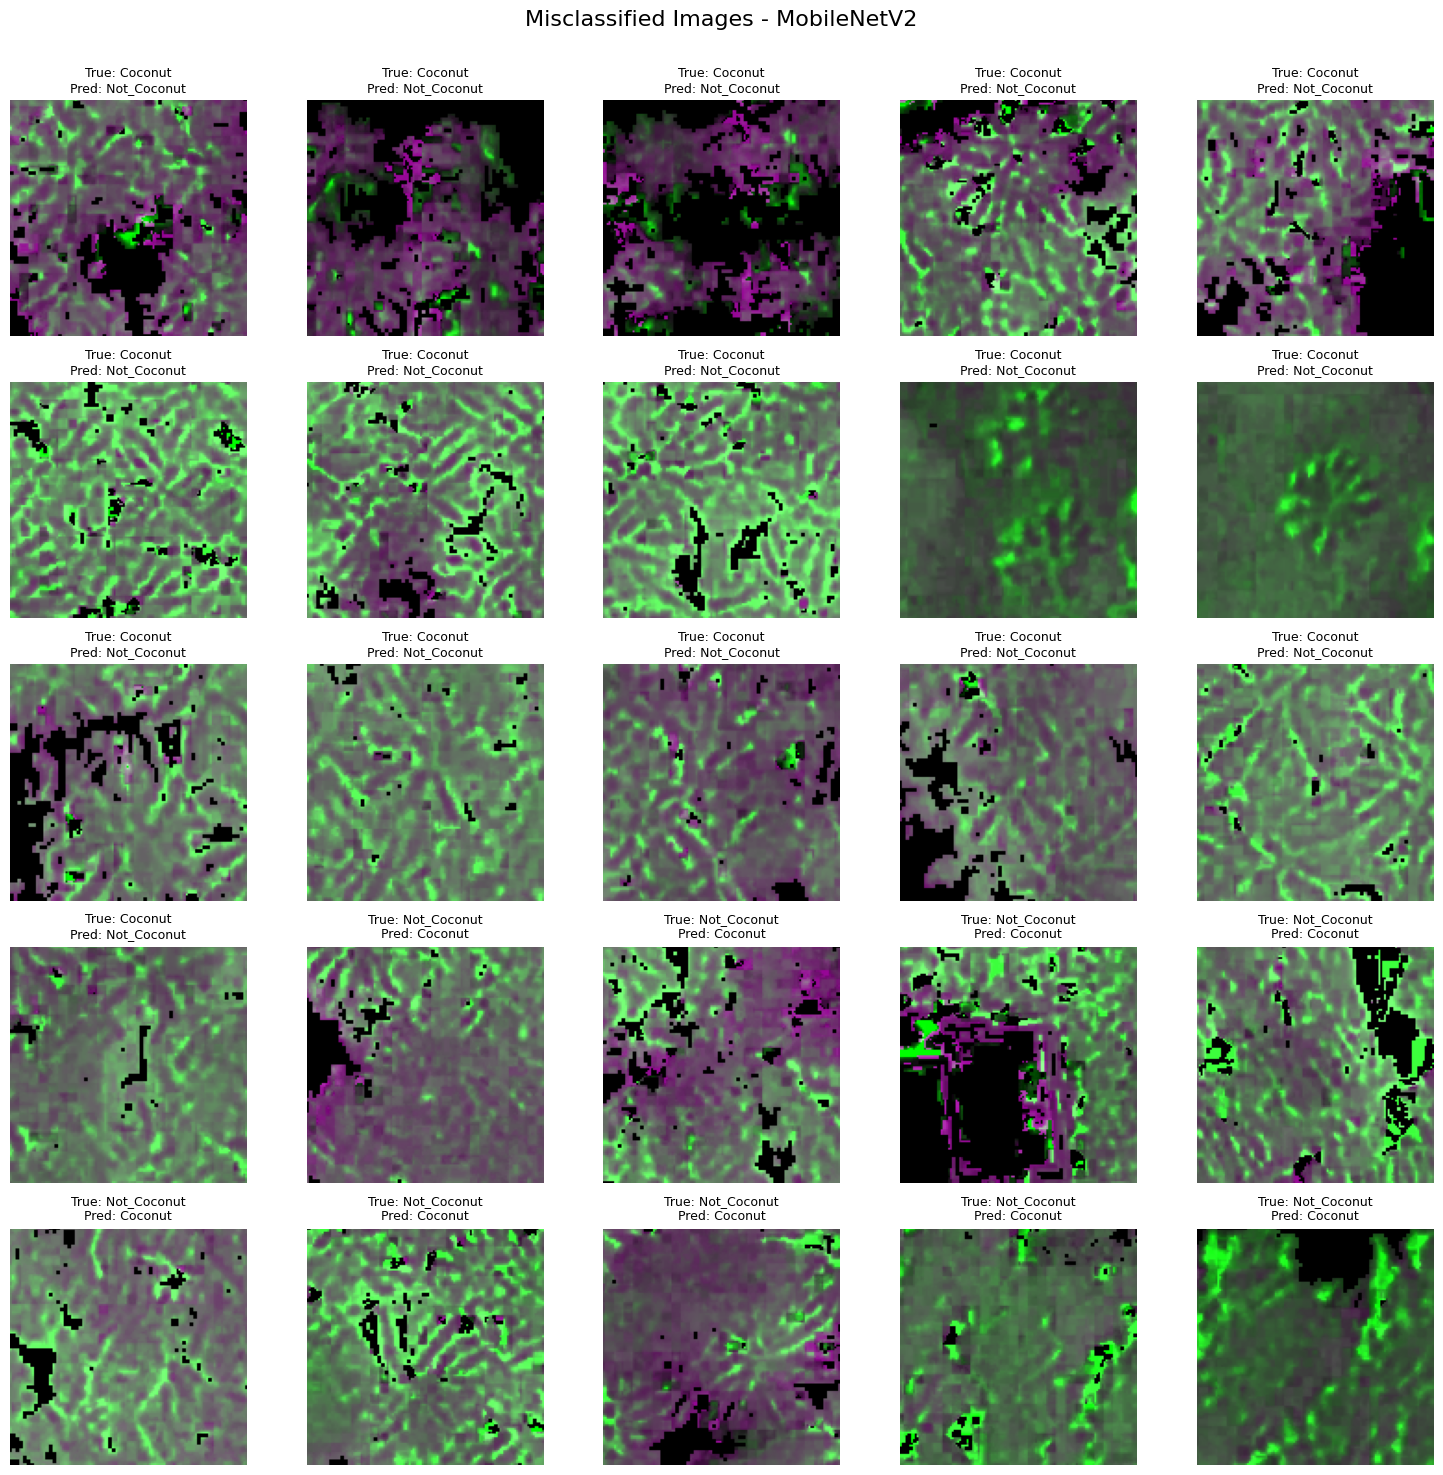

In [ ]:
import torch
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ======== Parameters ========
test_dir = r'/content/drive/Othercomputers/My Laptop/Project/Coconut Plantation/Applicatno/Texture Classification/Amrita_HS_split/test'
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======== Transforms ========
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Use 224 for MobileNetV2
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ======== Load Test Dataset ========
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = test_dataset.classes
num_classes = len(class_names)

# ======== Load MobileNetV2 Model ========
model = models.mobilenet_v2(pretrained=False)

# Replace classifier layer (IMPORTANT)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, num_classes)

# Load trained weights
model.load_state_dict(torch.load('/content/drive/MyDrive/Project/Coconut Plantation/Applicatno/Texture Classification/mobilenetv2_final.pth', map_location=device))

model.to(device)
model.eval()

# ======== Inference and Collect Predictions ========
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Get file paths
all_paths = [s[0] for s in test_dataset.samples]

# ======== Plot Misclassified Images ========
misclassified_indices = [
    i for i, (pred, true) in enumerate(zip(all_preds, all_labels))
    if pred != true
]

if not misclassified_indices:
    print("No misclassifications found.")
else:
    print(f"Found {len(misclassified_indices)} misclassified images.")

    num_to_show = min(25, len(misclassified_indices))
    plt.figure(figsize=(15, 15))

    for i, idx in enumerate(misclassified_indices[:num_to_show]):
        image_path = all_paths[idx]
        image = plt.imread(image_path)

        plt.subplot(5, 5, i + 1)
        plt.imshow(image)
        plt.axis('off')
        plt.title(
            f"True: {class_names[all_labels[idx]]}\n"
            f"Pred: {class_names[all_preds[idx]]}",
            fontsize=9
        )

    plt.tight_layout()
    plt.suptitle("Misclassified Images - MobileNetV2", fontsize=16)
    plt.subplots_adjust(top=0.92)
    plt.show()

<Figure size 3000x3000 with 0 Axes>

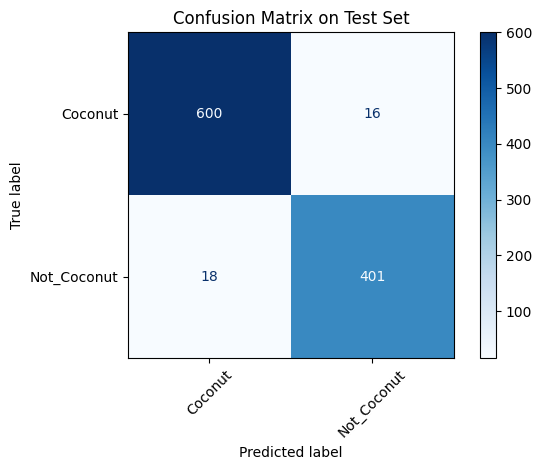

In [ ]:
import torch
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import os

# ======== Parameters ========
test_dir = r'/content/drive/Othercomputers/My Laptop/Project/Coconut Plantation/Applicatno/Texture Classification/Amrita_HS_split/test'
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======== Transforms ========
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ======== Load Test Dataset ========
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = test_dataset.classes
num_classes = len(class_names)

# ======== Load Model ========
model = models.mobilenet_v2(pretrained=False)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, num_classes)
model.load_state_dict(torch.load('/content/drive/MyDrive/Project/Coconut Plantation/Applicatno/Texture Classification/mobilenetv2_final.pth', map_location=device))
model.to(device)
model.eval()

# ======== Inference and Collect Predictions ========
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ======== Confusion Matrix ========
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(30, 30))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()
